In [1]:
# Import modules
import pandas as pd
import numpy as np
import xarray as xr
import scipy.stats as sp
import matplotlib.pyplot as plt
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
import re
import os

from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import BoundaryNorm

import sys
sys.path.insert(1, '../Modules/')
from EPE_detection import *

## Step-1 - set up parameters

Define the quantile threshold for identifying extreme or intense precipitation events.

In [2]:
threshold_widget=widgets.Dropdown(
    options=[85, 90, 95, 99],
    value=90,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)

threshold_widget

Dropdown(description='Threshold:', index=1, layout=Layout(width='200px'), options=(85, 90, 95, 99), style=Desc…

Define the accumulation period (days).

In [3]:
accumulation_widget = widgets.IntSlider(
    value=3,                    # Default value
    min=1,                      # Minimum duration
    max=5,                     # Maximum duration  
    step=2,                     # Step size
    description='Accumulation days:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

accumulation_widget

IntSlider(value=3, description='Accumulation days:', layout=Layout(width='400px'), max=5, min=1, step=2, style…

In [4]:
# check the values
quantile=threshold_widget.value/100
accumulation_time=accumulation_widget.value

print ("Threshold: ", quantile)
print ("Accumulation time: ", accumulation_time)

Threshold:  0.9
Accumulation time:  3


In [5]:
# years for quantiles definition
first_clima_year = 1993
last_clima_year = 2016

# define the threshold for dry days
dry_threshold = 0.2*1e-3 # m/day

# define dictionary for seasons
season = 'AMJ'
seasonal_dict = {
    'JFM' : {'pred_date':'-12-31', 'months': [1, 2, 3]},
    'FMA' : {'pred_date':'-01-31',  'months': [2, 3, 4]},
    'MAM' : {'pred_date':'-02-28',  'months': [3, 4, 5]},
    'AMJ' : {'pred_date':'-03-31',  'months': [4, 5, 6]},
    'MJJ' : {'pred_date':'-04-30',  'months': [5, 6, 7]},
    'JJA' : {'pred_date':'-05-31',  'months': [6, 7, 8]},
    'JAS' : {'pred_date':'-06-30',  'months': [7, 8, 9]},
    'ASO' : {'pred_date':'-07-31',  'months': [8, 9, 10]},
    'SON' : {'pred_date':'-08-31',  'months': [9, 10, 11]},
    'OND' : {'pred_date':'-09-30',  'months': [10, 11, 12]},
    'NDJ' : {'pred_date':'-10-31',  'months': [11, 12, 1]},
    'DJF' : {'pred_date':'-11-30',  'months': [12, 1, 2]}
}
months = seasonal_dict[season]['months']

# Step-2 - select location

Select the target location within Europe.

In [6]:
region="Cluj-Napoca"
lon='''23°33'00"E'''
lat='''46°46'00"N'''

# region = 'Southern-France'
# lon='''5°30'0"E'''
# lat='''45°30'0"N'''

# region = 'Denmark'
# lon='''9°15'0"E'''
# lat='''56°0'0"N'''

# region = 'Gerona'
# lon='''2°49'0"E'''
# lat='''41°59'0"N'''

# region = 'Bodo'
# lon='''14°22'30.36"E'''
# lat='''67°16'57.72"N'''

# region = 'Notthingam'
# lon='''1°9'4"W'''
# lat='''52°57'22"N'''

# region="Milano"
# lon='''09°11'24"E'''
# lat='''45°28'01"N'''

# region="London"
# lon = '''0°7'39"W'''
# lat = '''51°30'26"N'''





# Converts coords to integer value
deg, minutes, seconds, direction =  re.split('[°\'"]', lat)
latP= (float(deg) + float(minutes)/60 + float(seconds)/(60*60)) * (-1 if direction in ['W', 'S'] else 1)
deg, minutes, seconds, direction =  re.split('[°\'"]',lon)
lonP= (float(deg) + float(minutes)/60 + float(seconds)/(60*60)) * (-1 if direction in ['W', 'S'] else 1)

# Step-3 - Data

Inspect the dataset to better understand its structure and characteristics.

In [7]:
# open the daily time series of ERA5 TP over the European domain
era5_TP = xr.open_mfdataset('../DATA/ERA5_EU_TP_daily_sum_*',
                                combine='by_coords')['tp'].rename({'valid_time':'time'})

In [8]:
era5_TP

<xarray.DataArray 'tp' (time: 31047, latitude: 169, longitude: 249)> Size: 5GB
dask.array<concatenate, shape=(31047, 169, 249), dtype=float32, chunksize=(183, 85, 125), chunktype=numpy.ndarray>
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 1kB 71.0 70.75 70.5 70.25 ... 29.5 29.25 29.0
  * longitude  (longitude) float64 2kB -17.0 -16.75 -16.5 ... 44.5 44.75 45.0
  * time       (time) datetime64[ns] 248kB 1940-01-01 1940-01-02 ... 2024-12-31
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      42081
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [9]:
# select the grid point of interest
era5_TP_loc = era5_TP.sel(latitude=latP, longitude=lonP, method='nearest').load()
era5_TP_loc

<xarray.DataArray 'tp' (time: 31047)> Size: 124kB
array([5.6028366e-04, 2.2125244e-04, 6.0558319e-05, ..., 1.6927719e-03,
       1.7976761e-04, 3.5762787e-05], shape=(31047,), dtype=float32)
Coordinates:
    number     int64 8B 0
    latitude   float64 8B 46.75
    longitude  float64 8B 23.5
  * time       (time) datetime64[ns] 248kB 1940-01-01 1940-01-02 ... 2024-12-31
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      42081
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

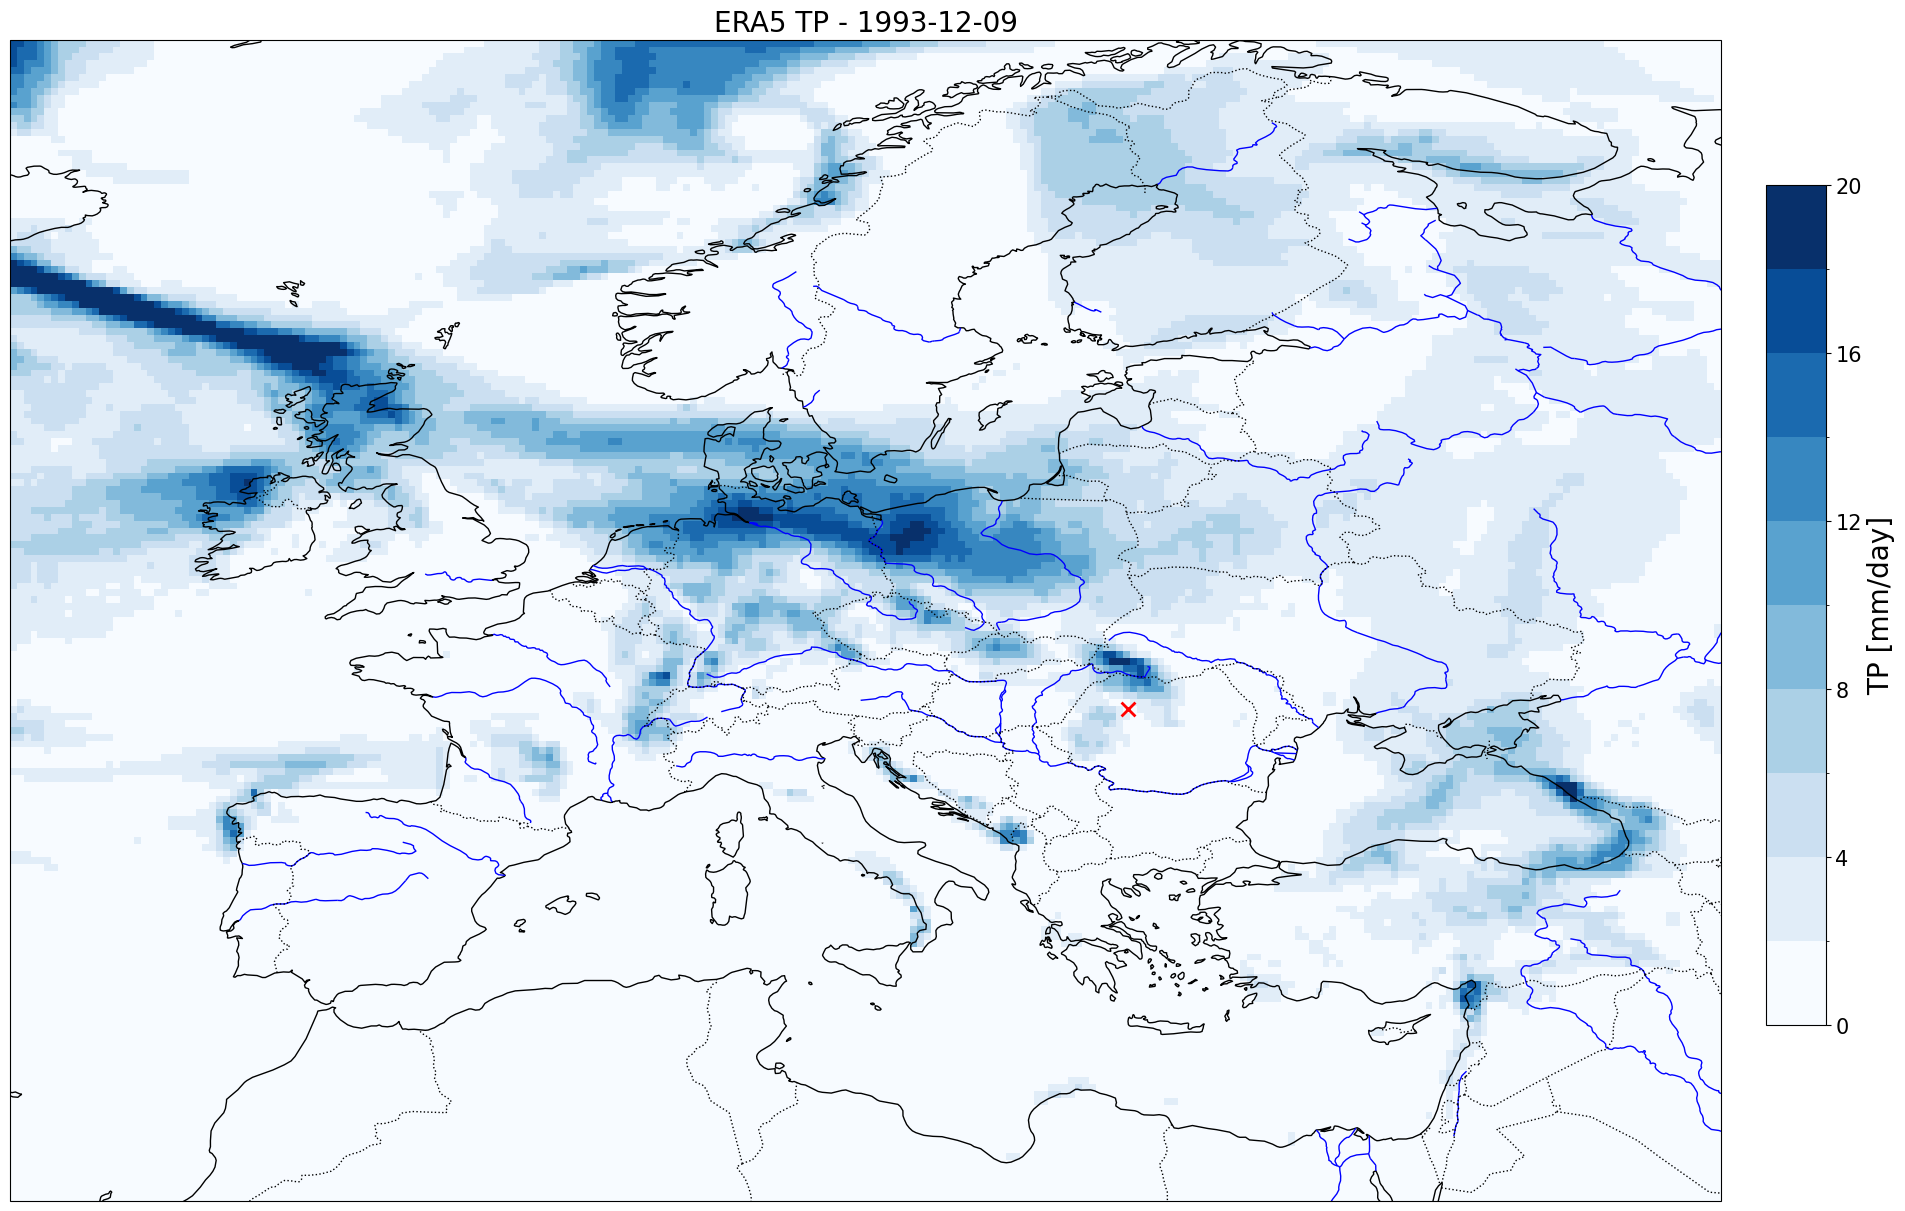

In [10]:
# plot of a random day TP

fig, ax = plt.subplots(figsize=(20, 12), subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)

axi=ax

# select a random day to look the data
rand_day = np.random.randint(0, len(era5_TP.time)-1)
era5_TP_rand_day = era5_TP.isel(time=rand_day)*1e3 # convert from m to mm

# set max value of the colormap
vmax = 20

# define the colormap
n_bins = 10 # adjust as needed
bounds = np.linspace(0, vmax, n_bins + 1)
cmap = plt.get_cmap("Blues", n_bins) 
norm = BoundaryNorm(bounds, cmap.N)

# plot the dataset
img = (era5_TP_rand_day).plot(ax=axi, transform=ccrs.PlateCarree(), add_colorbar=False, cmap = cmap, norm=norm)

# add coastlines, rivers, borders
axi.coastlines()
axi.add_feature(cfeature.RIVERS, edgecolor="blue")
axi.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="black")

# define the title
axi.set_title('ERA5 TP - {}'.format(era5_TP_rand_day.time.dt.strftime('%Y-%m-%d').values), fontsize=20)

# define the colormap details
cbar_ax = fig.add_axes([0.95, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cbar_ax, label="TP [mm/day]", ticks=None)
cbar.set_label("TP [mm/day]", fontsize=20)
cbar.ax.tick_params(labelsize=15) 


# report the selected grif point
axi.scatter(lonP, latP, 
            color='r',        # choose any colour you like
            s=100,              # size of the marker
            marker='x',         # 'x' for an X marker
            linewidth=2,        # thickness of the X lines
            transform=ccrs.PlateCarree(),
            label='Selected Point')

#plt.tight_layout()

#plt.savefig(path+'figures/{}q_{}_{}_{}.png'.format(quantile*100, period, first_clima_year, last_clima_year), bbox_inches='tight')

# Show the plot
plt.show()

In [11]:
# select only the season of interest
era5_TP_loc_seas = era5_TP_loc.where(era5_TP_loc['time'].dt.month.isin(months), drop=True)

# call the function to calculate the accumulated time series and skip dry days
era5_TP_loc_seas_acc = timeseries_processing(era5_TP_loc_seas, dry_threshold, accumulation_time, months)

# define a dataset just for climatology years
era5_TP_loc_seas_acc_clima = era5_TP_loc_seas_acc.sel(time=(era5_TP_loc_seas_acc['time'].dt.year >= first_clima_year) & (era5_TP_loc_seas_acc['time'].dt.year <= last_clima_year))

# calculate the selected quantile from the climatology years
q_era5_TP_loc_seas_acc = era5_TP_loc_seas_acc_clima.quantile(quantile, dim=('time'), skipna=True)

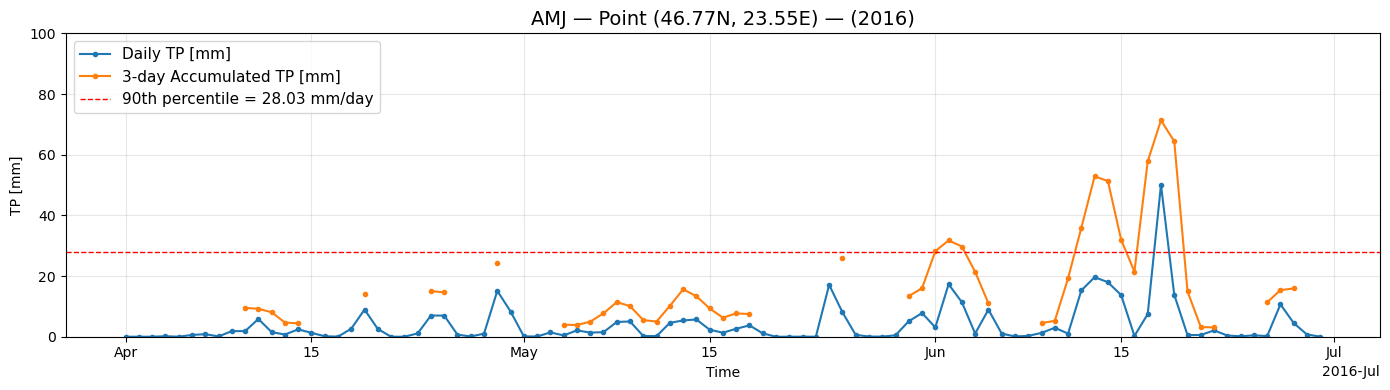

In [12]:
# plot
year = 2016

fig, ax = plt.subplots(figsize=(14,4))

# timeseries in mm
ts = (era5_TP_loc_seas.sel(time=era5_TP_loc_seas.time.dt.year == year) * 1000)
ts_acc = (era5_TP_loc_seas_acc.sel(time=era5_TP_loc_seas_acc.time.dt.year == year) * 1000)

# plot daily timeseries
ts.plot(ax=ax, color='C0', linewidth=1.5, label='Daily TP [mm]', ls='-', marker='.')
ts_acc.plot(ax=ax, color='C1', linewidth=1.5, label=f'{accumulation_time}-day Accumulated TP [mm]', ls='-', marker='.')

# quantile horizontal line (mm)
q_mm = float(q_era5_TP_loc_seas_acc.values) * 1000
q_label = f"{int(quantile*100)}th percentile = {q_mm:.2f} mm/day"
ax.axhline(q_mm, color='red', linestyle='--', linewidth=1, label=q_label)

# PQ for year (scalar)
title = f"{season} — Point ({latP:.2f}N, {lonP:.2f}E) — ({year})"
ax.set_title(title, fontsize=14)

# labels, grid, legend
ax.set_ylabel('TP [mm]')
ax.set_xlabel('Time')
ax.set_ylim([0, 100])
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=11)


plt.tight_layout()
plt.show()

# Step-4 - Extereme/intense Precipitation Events (EPE) detection

Compute the number of days with accumulation exceeding the selected quantile.

In [13]:
# define the NQp (i.e. the number of days in season, above the Qth percentile threshold)
NQp_era5_TP_loc_seas_acc = (era5_TP_loc_seas_acc > q_era5_TP_loc_seas_acc).groupby("time.year").sum()

# assign the corresponding predictors date
NQp_era5_TP_loc_seas_acc['predictors_date'] = ((NQp_era5_TP_loc_seas_acc['year']).astype(str) + seasonal_dict[season]['pred_date']).astype('U10')

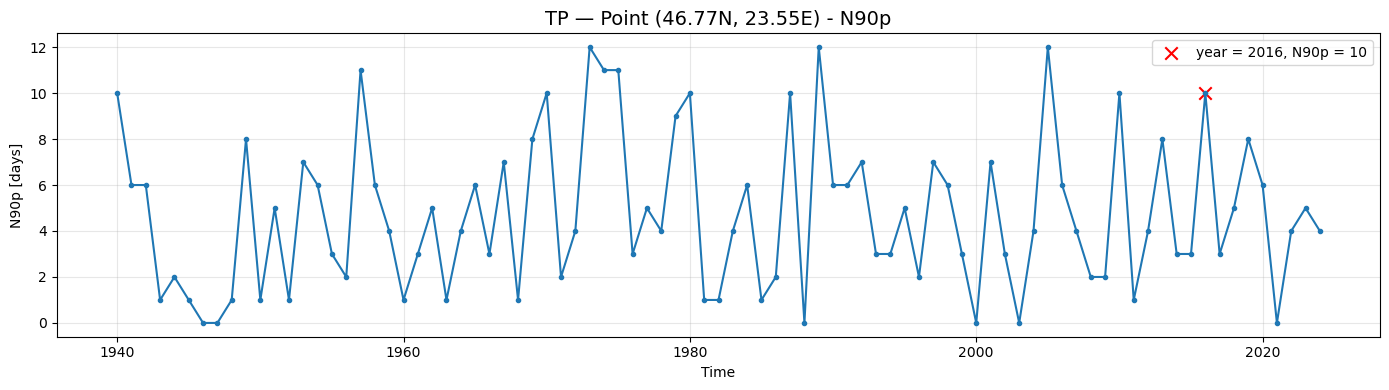

In [14]:
# plot the time series
fig, ax = plt.subplots(figsize=(14,4))

# timeseries in years
ts = NQp_era5_TP_loc_seas_acc

# plot yearly timeseries
ts.plot(ax=ax, color='C0', linewidth=1.5, ls='-', marker='.')
ax.scatter(year, ts.sel(year=year).values, color='r', marker='x', s=80, label='year = {}, N{}p = {}'.format(year, int(quantile*100), ts.sel(year=year).values))

ax.legend()
title = f"TP — Point ({latP:.2f}N, {lonP:.2f}E) - N{int(quantile*100)}p"
ax.set_title(title, fontsize=14)

# labels, grid, legend
ax.set_ylabel(f'N{int(quantile*100)}p [days]')
ax.set_xlabel('Time')
ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

# Step-5 -Oversampling

Since climate model simulations are not included, increase the dataset size using overlapping seasons as a data augmentation strategy.

In [15]:
# define the number of overlapping seasons
n_over_season = 5

day_shift_list = np.linspace(n_over_season//2*-7, n_over_season//2*7, n_over_season, dtype = int)

In [16]:
# calculate the NQp for the overlapping seasons
NQp_era5_TP_loc_seas_acc_over = overlapping_season(n_over_season, era5_TP_loc, q_era5_TP_loc_seas_acc, NQp_era5_TP_loc_seas_acc,
                                                   dry_threshold, accumulation_time, months)

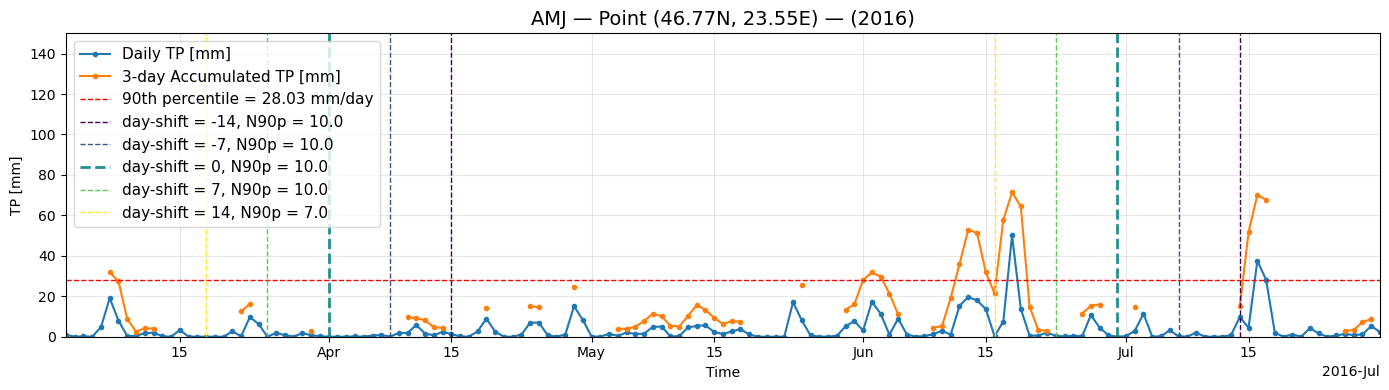

In [17]:
# plot
year = 2016

fig, ax = plt.subplots(figsize=(14,4))

# timeseries in mm
ts = era5_TP_loc.sel(time=((era5_TP_loc.time.dt.year == year) | (era5_TP_loc.time.dt.year == year+1))) * 1000
ts_acc = timeseries_processing(ts, dry_threshold*1000, accumulation_time, months)

# plot daily timeseries
ts.plot(ax=ax, color='C0', linewidth=1.5, label='Daily TP [mm]', ls='-', marker='.')
ts_acc.plot(ax=ax, color='C1', linewidth=1.5, label=f'{accumulation_time}-day Accumulated TP [mm]', ls='-', marker='.')

# quantile horizontal line (mm)
q_mm = float(q_era5_TP_loc_seas_acc.values) * 1000
q_label = f"{int(quantile*100)}th percentile = {q_mm:.2f} mm/day"
ax.axhline(q_mm, color='red', linestyle='--', linewidth=1, label=q_label)

# title
title = f"{season} — Point ({latP:.2f}N, {lonP:.2f}E) — ({year})"
ax.set_title(title, fontsize=14)

# plot the boundaries of the overlapping seasona
t0 = ts.where(ts['time'].dt.month.isin(months), drop=True).time.values[0]
t1 = ts.sel(time=((ts.time.dt.year == year))).where(ts['time'].dt.month.isin(months), drop=True).time.values[-1]

#color_list = ['purple', 'deepskyblue', 'black', 'darkorange', 'limegreen']
cmap = plt.get_cmap('viridis')  # choose any colormap
color_list = cmap(np.linspace(0, 1, len(day_shift_list)))

for day_shift, color in zip(day_shift_list, color_list):

     t0_str = (t0+pd.Timedelta(days=(-day_shift-1))).strftime('%Y-%m-%d')#.astype('U10')
     ax.axvline(t0+pd.Timedelta(days=(-day_shift)), color=color, linestyle='--', linewidth=2 if day_shift == 0 else 1,
      label=f'day-shift = {day_shift}, N{int(quantile*100)}p = {NQp_era5_TP_loc_seas_acc_over.sel(predictors_date=t0_str).tp.values}')
     ax.axvline(t1+pd.Timedelta(days=(-day_shift)), color=color, linestyle='--', linewidth=2 if day_shift == 0 else 1)


# labels, grid, legend
ax.set_ylabel('TP [mm]')
ax.set_xlabel('Time')
ax.set_ylim([0, 150])
ax.set_xlim([t0+pd.Timedelta(days=(-30)), t1+pd.Timedelta(days=(30))])
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=11)

# NB note that (for graphical purpose) in this visualisation the values
# on the first and last days of central season is not displayed


plt.tight_layout()
plt.show()

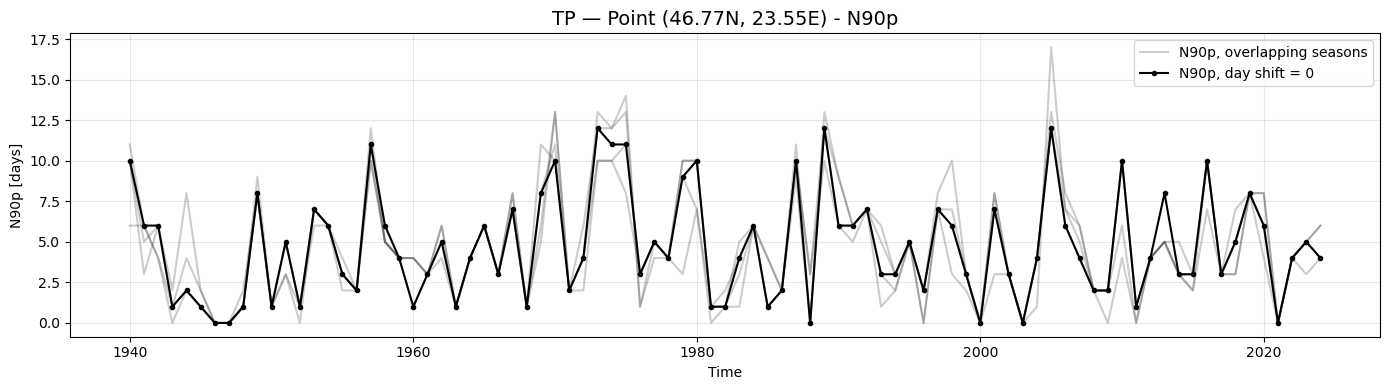

In [18]:
# plot the time series
fig, ax = plt.subplots(figsize=(14,4))

for i, day_shift in enumerate(day_shift_list):

    # timeseries in years
    ts = NQp_era5_TP_loc_seas_acc_over.tp[i::len(day_shift_list)]

    # plot yearly timeseries
    label = (
            'N{}p, day shift = {}'.format(int(quantile*100), day_shift)
            if day_shift == 0
            else 'N{}p, overlapping seasons'.format(int(quantile*100))
            if day_shift == day_shift_list[0]
            else ''
            )
    ax.plot(pd.to_datetime(ts.predictors_date).year,ts.values, linewidth=1.5, ls='-', marker='.' if day_shift==0 else '',
            label=label, color='k',
            alpha = 1 if day_shift==0 else 0.2)
    

ax.legend()
title = f"TP — Point ({latP:.2f}N, {lonP:.2f}E) - N{int(quantile*100)}p"
ax.set_title(title, fontsize=14)

# labels, grid, legend
ax.set_ylabel(f'N{int(quantile*100)}p [days]')
ax.set_xlabel('Time')
ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

# Step-6 - Save data

Save the data required for subsequent notebooks.

In [19]:
# Create a pandas dataframe
N90p_loc_seas_df = pd.DataFrame({'Target': NQp_era5_TP_loc_seas_acc_over.tp.values},
                                index=pd.to_datetime(NQp_era5_TP_loc_seas_acc_over['predictors_date'].values))
N90p_loc_seas_df.index.name = 'pred_date'


# convert index to object
N90p_loc_seas_df.index = N90p_loc_seas_df.index.strftime("%Y-%m-%d")

target_dataset = N90p_loc_seas_df

In [20]:
# Create filename
filename = f"Output/N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv"

# Remove existing file if it exists
if os.path.exists(filename):
    os.remove(filename)

In [21]:
# Save to CSV
target_dataset.to_csv(filename, index=True)

print(f"Saved heat wave days data to {filename}")

Saved heat wave days data to Output/N90p_Cluj-Napoca_ac3.csv
